# Reto 04 — OPT · Búsqueda de hiperparámetros con Optuna
### Despacho de una microred (solar + eólico + batería + red), bi-objetivo

Este notebook busca los mejores hiperparámetros de **NSGA-II** y **SPEA2** para el problema de despacho de la microred, usando **Optuna (TPE)** en lugar de un grid exhaustivo.

**Estrategia**
- Métrica de calidad: **Hypervolume (HV)** — mayor es mejor.
- Robustez: cada configuración se ejecuta `N_RUNS` veces con semillas distintas; se reporta la **mediana** del HV.
- Hiperparámetros buscados (rangos **continuos**): `eta_c` (SBX), `eta_m` (PM), `crossover_prob`.
- La población queda fija en `POPULATION_SIZE`.
- Un *study* de Optuna por algoritmo (se conserva la comparación NSGA-II vs SPEA2).

> **Modelo con batería**: el individuo es el **calendario completo** de `T_HOURS` horas con **3·T variables** por cromosoma: `x1_t` (solar), `x2_t` (eólico), `b_t` (carga/descarga de batería). Las horas dejan de ser independientes porque el nivel de carga de la batería en cada instante depende de todas las decisiones anteriores, creando un trade-off real entre ingresos y cobertura de déficit.

## 1. Imports y configuración

In [11]:
import os, random, time, json, warnings, logging
import numpy as np
import pandas as pd
import optuna

from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.algorithm.multiobjective.spea2 import SPEA2
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.core.quality_indicator import HyperVolume

warnings.filterwarnings('ignore')
logging.getLogger('jmetal').setLevel(logging.ERROR)

### CONFIGURACIÓN GLOBAL

In [33]:
BASE_SEED = 42  # Semilla base para reproducibilidad

# Rutas
DATA_DIR1   = '../data/raw'  
DATA_DIR2   = '../data/processed' 
DATA_DIR3   = '../data/results'   
OUTPUT_DIR = '/resultados'

# --- Horizonte de optimización --------------------------------------------
# El individuo = calendario completo de la ventana.
# Hay 3*T variables: para cada hora t, x1_t (solar), x2_t (eólico), b_t (batería).
# T_HOURS controla el tamaño de la ventana:
#   24 = un día | 168 = una semana | 720 = un mes | 8760 = año completo
T_HOURS    = 24    # ventana representativa (1 semana) -> 504 variables
START_HOUR = 0      # hora de inicio dentro del año (0 .. 8759 - T_HOURS)
PRED_YEAR  = 2020   # año de las predicciones de potencia (2017-2020 disponibles)

# --- Parámetros de la batería ---------------------------------------------
# La capacidad se define como X horas de demanda media (recomendación: 2-4 h).
# Se configura TRAS cargar datos (ver celda de datos), pero se puede anticipar aquí.
BATTERY_HOURS   = 3.0   # capacidad = BATTERY_HOURS * demanda_media [kWh]
BATTERY_EFF_C   = 0.95  # eficiencia de carga   (energía que entra en la batería)
BATTERY_EFF_D   = 0.95  # eficiencia de descarga (energía que sale de la batería)
BATTERY_SOC_MIN = 0.10  # estado de carga mínimo (fracción de capacidad)
BATTERY_SOC_MAX = 0.90  # estado de carga máximo (fracción de capacidad)
BATTERY_SOC_INI = 0.50  # estado de carga inicial (fracción de capacidad)

# --- Presupuesto evolutivo ------------------------------------------------
# max_evaluations = POPULATION_SIZE * GENERATIONS (igual para NSGA-II y SPEA2)
GENERATIONS     = 500
POPULATION_SIZE = 200  
N_RUNS = 3 

# Optuna
N_TRIALS   = 40 # nº de configuraciones que explora Optuna por algoritmo
ALGORITHMS = ['NSGAII', 'SPEA2']

# Espacio de búsqueda
SEARCH_SPACE = {
    'eta_c'          : (5.0, 30.0),   # índice de distribución SBX  (5=explorador, 30=explotador)
    'eta_m'          : (5.0, 30.0),   # índice de distribución PM
    'crossover_prob' : (0.7, 1.0),    # probabilidad de cruce SBX (literatura: >=0.7)
}

print('Configuración cargada.')
print(f'  Ventana            : {T_HOURS} h  (desde la hora {START_HOUR})  -> {3*T_HOURS} variables')
print(f'  Año predicciones   : {PRED_YEAR}')
print(f'  Batería            : {BATTERY_HOURS} h de demanda media | SOC [{BATTERY_SOC_MIN:.0%}, {BATTERY_SOC_MAX:.0%}]')
print(f'  Población (fija)   : {POPULATION_SIZE}')
print(f'  Generaciones       : {GENERATIONS}')
print(f'  Runs por config    : {N_RUNS}')
print(f'  Trials Optuna/algo : {N_TRIALS}')


Configuración cargada.
  Ventana            : 24 h  (desde la hora 0)  -> 72 variables
  Año predicciones   : 2020
  Batería            : 3.0 h de demanda media | SOC [10%, 90%]
  Población (fija)   : 200
  Generaciones       : 500
  Runs por config    : 3
  Trials Optuna/algo : 40


## 2. Carga y alineación de datos

In [52]:
# IMPORTANTE: los ficheros NO comparten fechas absolutas
#   - precios (solar/eólico/red): año 2025, horario  (8760 h)
#   - predicciones de potencia  : 2017-2020, horario  (~4 años)
#   - demanda (restaurante)     : sin fecha, 8760 valores horarios
# Por eso la alineación es POSICIONAL (hora-del-año, índice 0..8759).
# Tomamos un año de predicciones (PRED_YEAR) y emparejamos por posición.

# Demanda d_t (kW = kWh/h)
dem = pd.read_csv(os.path.join(DATA_DIR1, 'demanda_restaurante.csv'))
d_full = dem.iloc[:, 0].to_numpy(dtype=float) # [kWh/h]

# Precio de la red, precio solar y eólico (€/MWh -> €/kWh) 
pg = pd.read_csv(os.path.join(DATA_DIR1, 'Precios', 'precio2025-peninsula.csv'), sep=';')
a_grid_full = pg['value'].to_numpy(dtype=float) / 1000.0  # [€/kWh]
ps = pd.read_csv(os.path.join(DATA_DIR2, 'Precios', 'precio_solar_mwh.csv'),  sep=';')
pe = pd.read_csv(os.path.join(DATA_DIR2, 'Precios', 'precio_eolico_mwh.csv'), sep=';')
a_solar_full = ps['precio_eur_mwh'].to_numpy(dtype=float) / 1000.0  # [€/kWh]
a_wind_full  = pe['precio_eur_mwh'].to_numpy(dtype=float) / 1000.0  # [€/kWh]

# Capacidad solar P_solar_t y eólica P_wind_t (kW = kWh/h) - Predecido por los agentes
sol = pd.read_csv(os.path.join(DATA_DIR3, 'Predicciones_Solar.csv'))
win = pd.read_csv(os.path.join(DATA_DIR3, 'Predicciones_Eolico.csv'))
sol['Date'] = pd.to_datetime(sol['Date'])
win['Date'] = pd.to_datetime(win['Date'])
Psolar_full = sol.loc[sol['Date'].dt.year == PRED_YEAR, 'SystemProduction_AS'].to_numpy(dtype=float)[:8760]
Pwind_full  = win.loc[win['Date'].dt.year == PRED_YEAR, 'Power_AE'].to_numpy(dtype=float)[:8760]

# Recorte a longitud común y a la ventana de optimización ---------------
N = min(len(d_full), len(a_grid_full), len(a_solar_full), len(a_wind_full),
        len(Psolar_full), len(Pwind_full))
sl = slice(START_HOUR, START_HOUR + T_HOURS)
assert START_HOUR + T_HOURS <= N, f'La ventana excede los datos disponibles (N={N}).'

DEMAND  = d_full[:N][sl]        # d_t      [kWh/h]
P_SOLAR = Psolar_full[:N][sl]   # P_solar_t [kWh/h]
P_WIND  = Pwind_full[:N][sl]    # P_wind_t  [kWh/h]
A_SOLAR = a_solar_full[:N][sl]  # a1_t [€/kWh]
A_WIND  = a_wind_full[:N][sl]   # a2_t [€/kWh]
A_GRID  = a_grid_full[:N][sl]   # a3_t [€/kWh]

DEMAND = DEMAND * 2
A_GRID = A_GRID * 1

T = len(DEMAND)
print(f'Datos alineados (posicionalmente). Horas en la ventana: T = {T}')
print(f'  Demanda      [kWh/h]: media {DEMAND.mean():.1f}  | max {DEMAND.max():.1f}')
print(f'  Cap. solar   [kWh/h]: media {P_SOLAR.mean():.1f} | max {P_SOLAR.max():.1f}')
print(f'  Cap. eólica  [kWh/h]: media {P_WIND.mean():.1f}  | max {P_WIND.max():.1f}')
print(f'  Precio solar [€/kWh]: media {A_SOLAR.mean():.4f}')
print(f'  Precio eólico[€/kWh]: media {A_WIND.mean():.4f}')
print(f'  Precio red   [€/kWh]: media {A_GRID.mean():.4f}')
print(f'  Horas solar mas barato que red : {(A_SOLAR < A_GRID).mean()*100:.1f}%')
print(f'  Horas eólico mas barato que red: {(A_WIND  < A_GRID).mean()*100:.1f}%')
print(f'  Horas en que renovables cubren la demanda: {((P_SOLAR+P_WIND) >= DEMAND).mean()*100:.1f}%')

# --- Capacidad de la batería (fijada tras conocer la demanda media) -----------
BATTERY_CAPACITY = BATTERY_HOURS * DEMAND.mean()   # [kWh]
BATTERY_SOC_MIN_KWH = BATTERY_SOC_MIN * BATTERY_CAPACITY
BATTERY_SOC_MAX_KWH = BATTERY_SOC_MAX * BATTERY_CAPACITY
BATTERY_SOC_INI_KWH = BATTERY_SOC_INI * BATTERY_CAPACITY

print(f'  Batería cap.       : {BATTERY_CAPACITY:.2f} kWh  ')
print(f'                       ({BATTERY_HOURS:.1f} h × {DEMAND.mean():.2f} kWh/h demanda media)')
print(f'  SOC rango          : [{BATTERY_SOC_MIN_KWH:.2f}, {BATTERY_SOC_MAX_KWH:.2f}] kWh')




Datos alineados (posicionalmente). Horas en la ventana: T = 24
  Demanda      [kWh/h]: media 68.3  | max 91.7
  Cap. solar   [kWh/h]: media 92.7 | max 742.9
  Cap. eólica  [kWh/h]: media 68.0  | max 77.2
  Precio solar [€/kWh]: media 0.1987
  Precio eólico[€/kWh]: media 0.1777
  Precio red   [€/kWh]: media 0.1619
  Horas solar mas barato que red : 29.2%
  Horas eólico mas barato que red: 0.0%
  Horas en que renovables cubren la demanda: 70.8%
  Batería cap.       : 204.82 kWh  
                       (3.0 h × 68.27 kWh/h demanda media)
  SOC rango          : [20.48, 184.34] kWh


## 2.b Diagnóstico: ¿son razonables la demanda, los precios y la batería?

El profesor indica tres condiciones para que el problema tenga sentido con algoritmos evolutivos:

1. **Demanda ≈ 70–80 % de la producción renovable media** → hay superávit en horas buenas y déficit en malas.
2. **Precio de red > precio renovable** (idealmente ×2–×3) → minimizar déficit tiene sentido económico.
3. **Capacidad de batería ≈ 2–4 h de demanda media** → la batería es útil pero no omnipotente.

Las celdas siguientes comprueban estos tres criterios sobre los datos reales y avisan si algo está desbalanceado.

1. DEMANDA vs PRODUCCIÓN RENOVABLE
  Producción renovable media : 160.74 kWh/h
  Demanda media              : 68.27 kWh/h
  Ratio demanda/producción   : 42.48%  (objetivo: 70–80%)
  Horas con SUPERÁVIT        : 70.8%
  Horas con DÉFICIT          : 29.2%
  ⚠️  Demanda baja (42%): habrá superávit casi siempre → batería siempre llena, poco reto.

2. PRECIOS: red vs renovables
  Precio solar medio  : 0.1987 €/kWh
  Precio eólico medio : 0.1777 €/kWh
  Precio red medio    : 0.1619 €/kWh
  Ratio red/solar (media)  : 0.91x  (objetivo: ≥2x)
  Ratio red/eólico (media) : 0.91x  (objetivo: ≥2x)
  % horas red > solar  : 29.2%
  % horas red > eólico : 0.0%
  ⚠️  Ratio red/solar (0.91x): la red es barata; minimizar déficit puede no tener sentido económico.
  ⚠️  Ratio red/eólico (0.91x): la red es barata; minimizar déficit puede no tener sentido económico.

3. BATERÍA
  Demanda media          : 68.27 kWh/h
  Capacidad batería      : 204.82 kWh  (3.0 h × demanda media)
  Déficit medio/hora     : 2.64

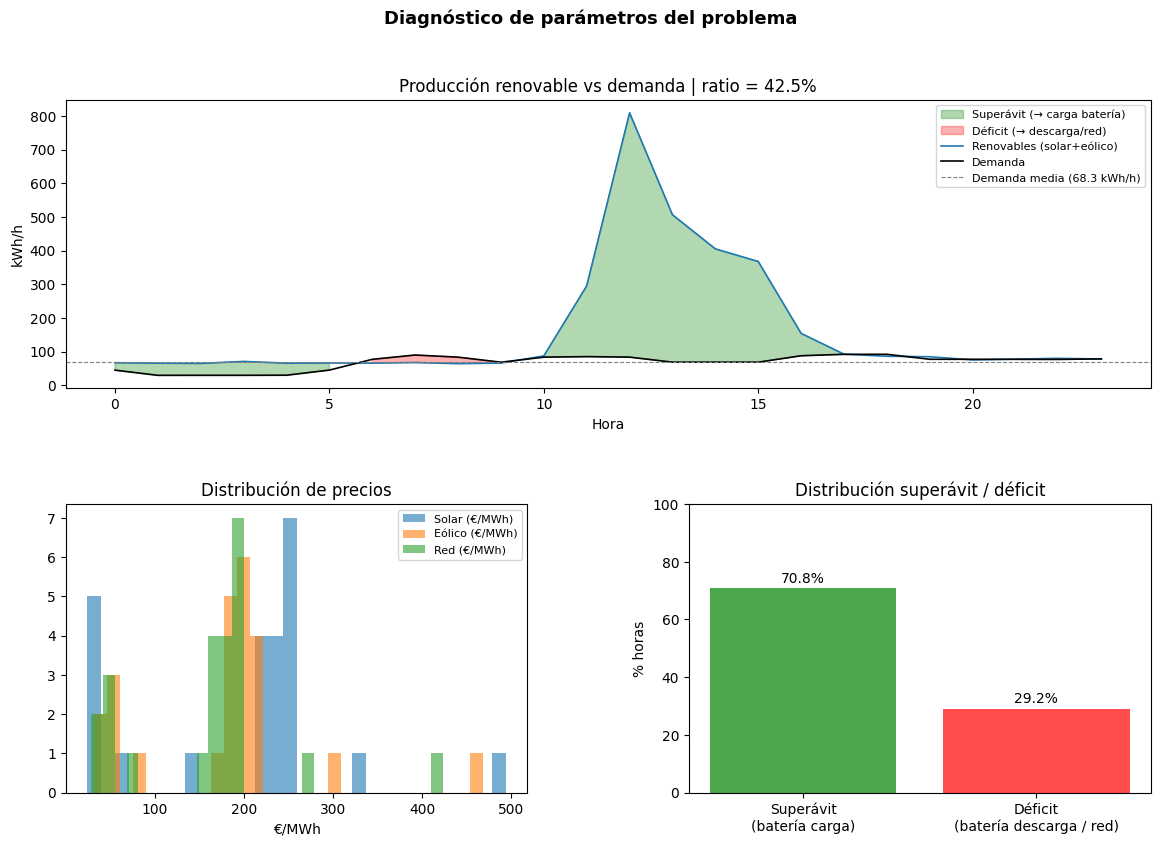

In [53]:
# ============================================================
#  DIAGNÓSTICO DE PARÁMETROS DEL PROBLEMA
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- 1. Ratio demanda / producción renovable media ----------------------------
prod_media   = (P_SOLAR + P_WIND).mean()   # kWh/h media de renovables
dem_media    = DEMAND.mean()                # kWh/h media de demanda
ratio_dem    = dem_media / prod_media        # idealmente 0.70 – 0.80

horas_superavit = ((P_SOLAR + P_WIND) >= DEMAND).mean() * 100  # % horas con superávit
horas_deficit   = 100 - horas_superavit

print('='*60)
print('1. DEMANDA vs PRODUCCIÓN RENOVABLE')
print('='*60)
print(f'  Producción renovable media : {prod_media:.2f} kWh/h')
print(f'  Demanda media              : {dem_media:.2f} kWh/h')
print(f'  Ratio demanda/producción   : {ratio_dem:.2%}  (objetivo: 70–80%)')
print(f'  Horas con SUPERÁVIT        : {horas_superavit:.1f}%')
print(f'  Horas con DÉFICIT          : {horas_deficit:.1f}%')
if 0.70 <= ratio_dem <= 0.80:
    print('  ✅  Ratio dentro del rango recomendado.')
elif ratio_dem < 0.70:
    print(f'  ⚠️  Demanda baja ({ratio_dem:.0%}): habrá superávit casi siempre → '
          'batería siempre llena, poco reto.')
else:
    print(f'  ⚠️  Demanda alta ({ratio_dem:.0%}): habrá déficit casi siempre → '
          'batería vacía, pierde utilidad.')

# --- 2. Proporción precio red vs renovables -----------------------------------
ratio_grid_solar = (A_GRID / np.where(A_SOLAR > 0, A_SOLAR, np.nan)).mean()
ratio_grid_wind  = (A_GRID / np.where(A_WIND  > 0, A_WIND,  np.nan)).mean()
pct_grid_mas_caro_solar = (A_GRID > A_SOLAR).mean() * 100
pct_grid_mas_caro_wind  = (A_GRID > A_WIND).mean()  * 100

print()
print('='*60)
print('2. PRECIOS: red vs renovables')
print('='*60)
print(f'  Precio solar medio  : {A_SOLAR.mean():.4f} €/kWh')
print(f'  Precio eólico medio : {A_WIND.mean():.4f} €/kWh')
print(f'  Precio red medio    : {A_GRID.mean():.4f} €/kWh')
print(f'  Ratio red/solar (media)  : {ratio_grid_solar:.2f}x  (objetivo: ≥2x)')
print(f'  Ratio red/eólico (media) : {ratio_grid_wind:.2f}x  (objetivo: ≥2x)')
print(f'  % horas red > solar  : {pct_grid_mas_caro_solar:.1f}%')
print(f'  % horas red > eólico : {pct_grid_mas_caro_wind:.1f}%')
for ratio, label in [(ratio_grid_solar, 'red/solar'), (ratio_grid_wind, 'red/eólico')]:
    if ratio >= 2.0:
        print(f'  ✅  Ratio {label} ({ratio:.2f}x): la red es suficientemente cara.')
    else:
        print(f'  ⚠️  Ratio {label} ({ratio:.2f}x): la red es barata; '
              'minimizar déficit puede no tener sentido económico.')

# --- 3. Capacidad de la batería -----------------------------------------------
print()
print('='*60)
print('3. BATERÍA')
print('='*60)
print(f'  Demanda media          : {dem_media:.2f} kWh/h')
print(f'  Capacidad batería      : {BATTERY_CAPACITY:.2f} kWh  ({BATTERY_HOURS:.1f} h × demanda media)')
print(f'  Déficit medio/hora     : {np.maximum(0, DEMAND - P_SOLAR - P_WIND).mean():.2f} kWh/h')
print(f'  Horas que batería cubre déficit medio: '
      f'{BATTERY_CAPACITY / max(np.maximum(0, DEMAND - P_SOLAR - P_WIND).mean(), 1e-9):.1f} h aprox.')
if 2.0 <= BATTERY_HOURS <= 4.0:
    print(f'  ✅  Capacidad ({BATTERY_HOURS:.1f} h) dentro del rango recomendado (2–4 h).')
elif BATTERY_HOURS < 2.0:
    print(f'  ⚠️  Batería pequeña ({BATTERY_HOURS:.1f} h): poca influencia en el frente de Pareto.')
else:
    print(f'  ⚠️  Batería grande ({BATTERY_HOURS:.1f} h): puede absorber todo el superávit '
          'y nunca haber déficit real.')

# --- 4. Gráfica de diagnóstico visual -----------------------------------------
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 4a. Producción vs demanda hora a hora
ax0 = fig.add_subplot(gs[0, :])
horas = np.arange(T)
ax0.fill_between(horas, P_SOLAR + P_WIND, DEMAND,
                 where=(P_SOLAR+P_WIND) >= DEMAND,
                 alpha=0.3, color='green', label='Superávit (→ carga batería)')
ax0.fill_between(horas, P_SOLAR + P_WIND, DEMAND,
                 where=(P_SOLAR+P_WIND) <  DEMAND,
                 alpha=0.3, color='red',   label='Déficit (→ descarga/red)')
ax0.plot(horas, P_SOLAR + P_WIND, label='Renovables (solar+eólico)', lw=1.2)
ax0.plot(horas, DEMAND,           label='Demanda',  lw=1.2, color='k')
ax0.axhline(dem_media, ls='--', color='gray', lw=0.8, label=f'Demanda media ({dem_media:.1f} kWh/h)')
ax0.set_title(f'Producción renovable vs demanda | ratio = {ratio_dem:.1%}')
ax0.set_xlabel('Hora')
ax0.set_ylabel('kWh/h')
ax0.legend(fontsize=8)

# 4b. Distribución de precios
ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(A_SOLAR * 1000, bins=30, alpha=0.6, label='Solar (€/MWh)')
ax1.hist(A_WIND  * 1000, bins=30, alpha=0.6, label='Eólico (€/MWh)')
ax1.hist(A_GRID  * 1000, bins=30, alpha=0.6, label='Red (€/MWh)')
ax1.set_title('Distribución de precios')
ax1.set_xlabel('€/MWh')
ax1.legend(fontsize=8)

# 4c. Proporción superávit/déficit
ax2 = fig.add_subplot(gs[1, 1])
ax2.bar(['Superávit\n(batería carga)', 'Déficit\n(batería descarga / red)'],
        [horas_superavit, horas_deficit],
        color=['green', 'red'], alpha=0.7)
ax2.set_ylabel('% horas')
ax2.set_title('Distribución superávit / déficit')
ax2.set_ylim(0, 100)
for bar, val in zip(ax2.patches, [horas_superavit, horas_deficit]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Diagnóstico de parámetros del problema', fontsize=13, fontweight='bold')
plt.show()


## 3. Definición del problema

In [54]:
# ============================================================
#  DEFINICIÓN DEL PROBLEMA  (despacho de microred, bi-objetivo, CON BATERÍA)
# ============================================================
# Variables (3*T):  [x1_0..x1_{T-1} | x2_0..x2_{T-1} | b_0..b_{T-1}]
#   x1_t = energía comprada al solar   en la hora t   (kWh)  [0, P_solar_t]
#   x2_t = energía comprada al eólico  en la hora t   (kWh)  [0, P_wind_t]
#   b_t  = variación de energía en la batería en hora t (kWh)
#          b_t > 0 → carga (absorbe energía del sistema)
#          b_t < 0 → descarga (aporta energía al consumidor)
#          rango:  [-BATTERY_CAPACITY, +BATTERY_CAPACITY]
#
# Estado de carga (SOC):
#   soc_0 = BATTERY_SOC_INI_KWH
#   soc_{t+1} = soc_t + b_t * eff_c   si b_t > 0  (carga)
#             = soc_t + b_t / eff_d   si b_t < 0  (descarga)
#   restricción: SOC_MIN <= soc_t <= SOC_MAX  (gestionada por reparación)
#
# Suministro neto al consumidor en hora t:
#   supply_t = x1_t + x2_t - b_t        (descarga aporta, carga resta)
#   grid_t   = max(0, d_t - supply_t)   (déficit cubierto por la red)
#
# Objetivos (ambos MINIMIZAR):
#   f1 = sum_t [ a1_t*x1_t + a2_t*x2_t + a3_t*grid_t ]   (coste total, €)
#   f2 = sum_t grid_t                                     (energía de red, kWh)
#
# Trade-off real creado por la batería:
#   - Estrategias de coste mínimo → no guardan en la batería
#     (cargar tiene coste de oportunidad: energía que no va al consumidor ahora)
#   - Estrategias de déficit mínimo → usan la batería activamente
#     para suavizar huecos de demanda entre horas

class MicrogridDispatch(FloatProblem):
    """Despacho bi-objetivo de una microred con batería (coste vs energía de red)."""

    def __init__(self, demand, p_solar, p_wind, a_solar, a_wind, a_grid,
                 bat_capacity, bat_soc_ini, bat_soc_min, bat_soc_max,
                 bat_eff_c, bat_eff_d):
        super().__init__()
        self.d    = np.asarray(demand,  dtype=float)
        self.ps   = np.asarray(p_solar, dtype=float)
        self.pw   = np.asarray(p_wind,  dtype=float)
        self.a1   = np.asarray(a_solar, dtype=float)
        self.a2   = np.asarray(a_wind,  dtype=float)
        self.a3   = np.asarray(a_grid,  dtype=float)
        self.T    = len(self.d)
        self.bat_cap     = bat_capacity
        self.bat_soc_ini = bat_soc_ini
        self.bat_soc_min = bat_soc_min
        self.bat_soc_max = bat_soc_max
        self.eff_c       = bat_eff_c
        self.eff_d       = bat_eff_d

        # ── CAMBIO: x1, x2 ya NO están limitadas por la demanda,
        #   sino solo por la capacidad de producción renovable.
        #   Ahora se puede comprar más de lo que se consume para cargar la batería.
        self.lower_bound = [0.0] * self.T + [0.0] * self.T + [-self.bat_cap] * self.T
        self.upper_bound = list(self.ps) + list(self.pw) + [self.bat_cap] * self.T
        self.obj_directions = [self.MINIMIZE, self.MINIMIZE]
        self.obj_labels     = ['Coste (€)', 'Energia red (kWh)']

    def number_of_variables(self)   -> int: return 3 * self.T
    def number_of_objectives(self)  -> int: return 2
    def number_of_constraints(self) -> int: return 0
    def name(self)                  -> str: return 'Microgrid Dispatch with Battery'

    def _repair(self, variables):
        x  = np.asarray(variables, dtype=float)
        x1 = np.clip(x[:self.T],         0.0, self.ps)
        x2 = np.clip(x[self.T:2*self.T], 0.0, self.pw)
        b  = np.clip(x[2*self.T:],       -self.bat_cap, self.bat_cap)

        # ── CAMBIO: eliminada la restricción x1+x2 <= d_t.
        #   Ahora se puede comprar superávit renovable para cargar la batería.
        #   La única restricción es que la carga no supere ese superávit.

        soc   = self.bat_soc_ini
        b_rep = np.empty(self.T)
        for t in range(self.T):
            bt = b[t]
            if bt >= 0:  # intento de carga
                # límite 1: no superar SOC_MAX
                max_charge = (self.bat_soc_max - soc) / self.eff_c
                bt = min(bt, max_charge)
                # límite 2: solo cargas con superávit renovable de esta hora
                # (superávit = lo que sobra DESPUÉS de cubrir la demanda)
                surplus = max(0.0, x1[t] + x2[t] - self.d[t])
                bt = min(bt, surplus)
                soc += bt * self.eff_c
            else:  # intento de descarga
                # límite: no bajar de SOC_MIN
                max_discharge = (soc - self.bat_soc_min) * self.eff_d
                bt = max(bt, -max_discharge)
                soc += bt / self.eff_d
            b_rep[t] = bt
        return x1, x2, b_rep

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        x1, x2, b = self._repair(solution.variables)
        solution.variables = np.concatenate([x1, x2, b]).tolist()

        # déficit = lo que la red tiene que cubrir tras renovables y batería
        deficit = np.maximum(0.0, self.d - x1 - x2 - b)

        # ── f1: pagas por TODO lo que compras (x1, x2), cargues o no la batería,
        #        más lo que cubre la red
        f1 = float(self.a1 @ x1 + self.a2 @ x2 + self.a3 @ deficit)
        f2 = float(deficit.sum())

        solution.objectives[0] = f1
        solution.objectives[1] = f2
        return solution


# Instanciar el problema sobre la ventana cargada (con batería)
problem = MicrogridDispatch(
    DEMAND, P_SOLAR, P_WIND, A_SOLAR, A_WIND, A_GRID,
    bat_capacity = BATTERY_CAPACITY,
    bat_soc_ini  = BATTERY_SOC_INI_KWH,
    bat_soc_min  = BATTERY_SOC_MIN_KWH,
    bat_soc_max  = BATTERY_SOC_MAX_KWH,
    bat_eff_c    = BATTERY_EFF_C,
    bat_eff_d    = BATTERY_EFF_D,
)
print(f'Problema listo: {problem.name()}')
print(f'Variables: {problem.number_of_variables()}  |  Objetivos: {problem.number_of_objectives()}')
print(f'  x1 (solar)  : {problem.T} variables  [0, P_solar_t]')
print(f'  x2 (eólico) : {problem.T} variables  [0, P_wind_t]')
print(f'  b  (batería): {problem.T} variables  [-{BATTERY_CAPACITY:.1f}, +{BATTERY_CAPACITY:.1f}] kWh')


Problema listo: Microgrid Dispatch with Battery
Variables: 72  |  Objetivos: 2
  x1 (solar)  : 24 variables  [0, P_solar_t]
  x2 (eólico) : 24 variables  [0, P_wind_t]
  b  (batería): 24 variables  [-204.8, +204.8] kWh


## 4. Cotas del espacio objetivo y punto de referencia del HV

In [55]:
# ============================================================
#  COTAS DEL ESPACIO OBJETIVO Y PUNTO DE REFERENCIA DEL HV
# ============================================================
# Con batería el problema ya NO es separable hora a hora, pero los extremos
# de cada objetivo se pueden acotar analíticamente ignorando la batería
# (límite inferior = mejor caso sin batería; la batería solo puede mejorar el déficit):
#
#   f2 (energía de red):
#     min = sum_t max(0, d_t - P_solar_t - P_wind_t)   (renovables al máximo)
#     max = sum_t d_t                                  (todo de la red)
#   f1 (coste): por hora se rellena la demanda
#     min -> fuentes mas baratas que la red primero
#     max -> fuentes mas caras que la red primero  (peor rincón factible)
#
# El punto de referencia del HV es el peor rincón (f1_max, f2_max) + margen,
# que GARANTIZA dominar todo el frente (mejor que muestrear: el muestreo aleatorio
# tiende a sobreusar renovables e infraestima el extremo de mucha energía de red).

def objective_bounds(d, ps, pw, a_s, a_w, a_g):
    f1_min = f1_max = 0.0
    for t in range(len(d)):
        srcs = [(a_s[t], ps[t]), (a_w[t], pw[t])]
        rem, c = d[t], 0.0                                   # coste mínimo
        for price, cap in sorted(srcs, key=lambda z: z[0]):
            if price < a_g[t]:
                u = min(cap, rem); c += price * u; rem -= u
        c += a_g[t] * rem; f1_min += c
        rem, c = d[t], 0.0                                   # coste máximo
        for price, cap in sorted(srcs, key=lambda z: -z[0]):
            if price > a_g[t]:
                u = min(cap, rem); c += price * u; rem -= u
        c += a_g[t] * rem; f1_max += c
    f2_min = float(np.maximum(0.0, d - ps - pw).sum())
    f2_max = float(d.sum())
    return f1_min, f1_max, f2_min, f2_max

MARGIN = 0.1
F1_MIN, F1_MAX, F2_MIN, F2_MAX = objective_bounds(DEMAND, P_SOLAR, P_WIND, A_SOLAR, A_WIND, A_GRID)
area_espacio    = (F1_MAX - F1_MIN) * (F2_MAX - F2_MIN)
REFERENCE_POINT = np.array([F1_MAX, F2_MAX]) * (1 + MARGIN)

print(f'f1 (coste)       : min {F1_MIN:.4f} €   | max {F1_MAX:.4f} €')
print(f'f2 (energia red) : min {F2_MIN:.2f} kWh | max {F2_MAX:.2f} kWh')
print(f'Área espacio objetivo: {area_espacio:.4f}')
print(f'Punto de referencia HV: coste={REFERENCE_POINT[0]:.4f} €, energia_red={REFERENCE_POINT[1]:.2f} kWh')

f1 (coste)       : min 255.9524 €   | max 285.1858 €
f2 (energia red) : min 63.40 kWh | max 1638.59 kWh
Área espacio objetivo: 46048.1775
Punto de referencia HV: coste=313.7044 €, energia_red=1802.44 kWh


## 5. Función auxiliar: ejecutar un algoritmo y calcular su HV

In [56]:
# ============================================================
#  EJECUTAR UN ALGORITMO Y DEVOLVER SU HYPERVOLUME
# ============================================================
def run_algorithm(algo_name: str, population_size: int, eta_c: float, eta_m: float,
                  crossover_prob: float, seed: int) -> dict:
    """Ejecuta NSGA-II o SPEA2 con los hiperparámetros dados y devuelve HV, nº de
    soluciones y tiempo."""
    random.seed(seed)
    np.random.seed(seed)

    mutation_prob   = 1.0 / problem.number_of_variables()   # regla estándar 1/n
    max_evaluations = population_size * GENERATIONS          # mismo presupuesto para ambos

    crossover_op = SBXCrossover(probability=crossover_prob, distribution_index=eta_c)
    mutation_op  = PolynomialMutation(probability=mutation_prob, distribution_index=eta_m)
    termination  = StoppingByEvaluations(max_evaluations=max_evaluations)

    t0 = time.time()
    if algo_name == 'NSGAII':
        algo = NSGAII(problem=problem, population_size=population_size,
                      offspring_population_size=population_size,
                      mutation=mutation_op, crossover=crossover_op,
                      termination_criterion=termination)
    elif algo_name == 'SPEA2':
        algo = SPEA2(problem=problem, population_size=population_size,
                     offspring_population_size=population_size,
                     mutation=mutation_op, crossover=crossover_op,
                     termination_criterion=termination)
    else:
        raise ValueError(f'Algoritmo desconocido: {algo_name}')

    algo.run()
    elapsed = time.time() - t0

    front     = get_non_dominated_solutions(algo.result())
    front_arr = np.array([s.objectives for s in front])
    hv_ind    = HyperVolume(REFERENCE_POINT.tolist())
    hv        = hv_ind.compute(front_arr.tolist()) if len(front) > 0 else 0.0

    return {'hv': hv, 'n_solutions': len(front), 'elapsed_s': elapsed}

print('Función run_algorithm definida.')

Función run_algorithm definida.


## 6. Búsqueda con Optuna

In [ ]:
# ============================================================
#  BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (TPE)
# ============================================================
# Un study por algoritmo (para conservar la comparación NSGA-II vs SPEA2).
# Se buscan eta_c, eta_m y crossover_prob (rangos CONTINUOS).
# Objetivo de Optuna: MAXIMIZAR la MEDIANA del HV sobre N_RUNS semillas.

optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(algo_name):
    def objective(trial):
        eta_c = trial.suggest_float('eta_c',          *SEARCH_SPACE['eta_c'])
        eta_m = trial.suggest_float('eta_m',          *SEARCH_SPACE['eta_m'])
        cx    = trial.suggest_float('crossover_prob', *SEARCH_SPACE['crossover_prob'])

        hv_runs, elapsed_runs = [], []
        for r in range(N_RUNS):
            seed = BASE_SEED + r * 1000
            try:
                out = run_algorithm(algo_name, POPULATION_SIZE, eta_c, eta_m, cx, seed)
                hv_runs.append(out['hv'])
                elapsed_runs.append(out['elapsed_s'])
            except Exception as e:
                print(f'  Error en {algo_name} run {r}: {e}')
                hv_runs.append(np.nan); elapsed_runs.append(np.nan)

        trial.set_user_attr('hv_mean',        float(np.nanmean(hv_runs)))
        trial.set_user_attr('hv_std',         float(np.nanstd(hv_runs)))
        trial.set_user_attr('hv_min',         float(np.nanmin(hv_runs)))
        trial.set_user_attr('hv_max',         float(np.nanmax(hv_runs)))
        trial.set_user_attr('elapsed_mean_s', float(np.nanmean(elapsed_runs)))
        trial.set_user_attr('hv_runs',        [float(h) for h in hv_runs])
        return float(np.nanmedian(hv_runs))   # se MAXIMIZA
    return objective

results   = []   # una fila por trial (de los dos algoritmos)
studies   = {}
best_params = {}

DB_PATH = 'sqlite:///optuna_microred.db'  # se guarda en optimizacion/

for algo_name in ALGORITHMS:
    print(f"\n{'='*60}\n Optuna -> {algo_name}\n{'='*60}")
    sampler = optuna.samplers.TPESampler(seed=BASE_SEED)
    study   = optuna.create_study(direction='maximize', sampler=sampler,
                                  study_name=algo_name, storage=DB_PATH,
                                  load_if_exists=True)
    study.optimize(make_objective(algo_name), n_trials=N_TRIALS, show_progress_bar=True)

    studies[algo_name]     = study
    best_params[algo_name] = study.best_params
    print(f'  Mejor HV (mediana) {algo_name}: {study.best_value:.6f}')
    print(f'  Mejores parámetros : {study.best_params}')

    for t in study.trials:
        results.append({
            'algorithm'      : algo_name,
            'population_size': POPULATION_SIZE,
            'eta_c'          : t.params.get('eta_c'),
            'eta_m'          : t.params.get('eta_m'),
            'crossover_prob' : t.params.get('crossover_prob'),
            'hv_median'      : t.value,
            'hv_mean'        : t.user_attrs.get('hv_mean'),
            'hv_std'         : t.user_attrs.get('hv_std'),
            'hv_min'         : t.user_attrs.get('hv_min'),
            'hv_max'         : t.user_attrs.get('hv_max'),
            'elapsed_mean_s' : t.user_attrs.get('elapsed_mean_s'),
            'hv_runs'        : t.user_attrs.get('hv_runs'),
        })

print('\nBúsqueda Optuna completada.')
print(f'Base de datos Optuna guardada en: {DB_PATH}')

## 6.a Ejecución directa sin búsqueda

Aquí ejecutamos una sola vez un algoritmo con valores fijos de hiperparámetros y mostramos el frente de Pareto resultante.

Ejecutando NSGAII con eta_c=20.0, eta_m=20.0, crossover_prob=0.9
Número de soluciones no dominadas: 193
Hypervolume frente de Pareto: 82856.027753
Coste  : min 264.3471 € | max 277.4507 €
Energía red: min 76.30 kWh | max 542.01 kWh
Dispersión del frente: spacing media 2.428072, std 1.409731


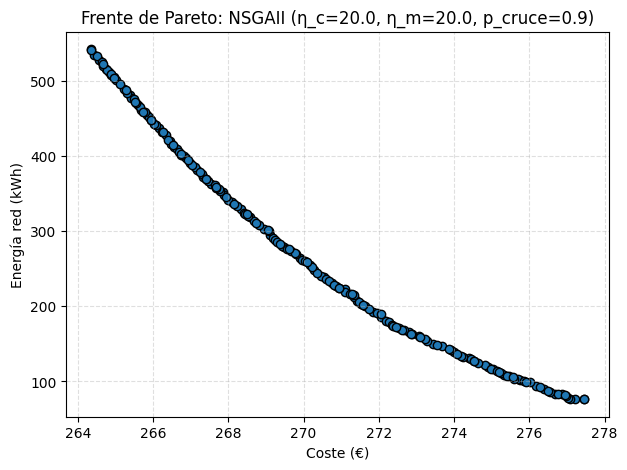

In [57]:
# ============================================================
#  EJECUCIÓN DIRECTA DEL ALGORITMO (SIN GRID SEARCH)
# ============================================================
algo_name = 'NSGAII'
eta_c = 20.0
eta_m = 20.0
crossover_prob = 0.9
#eta_c          = best_params['NSGAII']['eta_c']
#eta_m          = best_params['NSGAII']['eta_m']
#crossover_prob = best_params['NSGAII']['crossover_prob']
seed = BASE_SEED

print(f'Ejecutando {algo_name} con eta_c={eta_c}, eta_m={eta_m}, crossover_prob={crossover_prob}')

random.seed(seed)
np.random.seed(seed)
mutation_prob = 1.0 / problem.number_of_variables()
max_evaluations = POPULATION_SIZE * GENERATIONS

crossover_op = SBXCrossover(probability=crossover_prob, distribution_index=eta_c)
mutation_op = PolynomialMutation(probability=mutation_prob, distribution_index=eta_m)
termination = StoppingByEvaluations(max_evaluations=max_evaluations)

if algo_name == 'NSGAII':
    algo = NSGAII(problem=problem, population_size=POPULATION_SIZE,
                  offspring_population_size=POPULATION_SIZE,
                  mutation=mutation_op, crossover=crossover_op,
                  termination_criterion=termination)
elif algo_name == 'SPEA2':
    algo = SPEA2(problem=problem, population_size=POPULATION_SIZE,
                 offspring_population_size=POPULATION_SIZE,
                 mutation=mutation_op, crossover=crossover_op,
                 termination_criterion=termination)
else:
    raise ValueError(f'Algoritmo desconocido: {algo_name}')

algo.run()
front = get_non_dominated_solutions(algo.result())
front_arr = np.array([s.objectives for s in front])

hv_ind = HyperVolume(REFERENCE_POINT.tolist())
hv = hv_ind.compute(front_arr.tolist()) if len(front_arr) > 0 else 0.0

n_solutions = len(front_arr)
print(f'Número de soluciones no dominadas: {n_solutions}')
print(f'Hypervolume frente de Pareto: {hv:.6f}')

if n_solutions > 0:
    coste_min, coste_max = front_arr[:, 0].min(), front_arr[:, 0].max()
    energia_min, energia_max = front_arr[:, 1].min(), front_arr[:, 1].max()
    sorted_by_cost = front_arr[np.argsort(front_arr[:, 0])]
    distances = np.linalg.norm(np.diff(sorted_by_cost, axis=0), axis=1)
    spacing_mean = float(distances.mean()) if len(distances) > 0 else 0.0
    spacing_std = float(distances.std()) if len(distances) > 0 else 0.0

    print(f'Coste  : min {coste_min:.4f} € | max {coste_max:.4f} €')
    print(f'Energía red: min {energia_min:.2f} kWh | max {energia_max:.2f} kWh')
    print(f'Dispersión del frente: spacing media {spacing_mean:.6f}, std {spacing_std:.6f}')

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
if n_solutions > 0:
    plt.scatter(front_arr[:, 0], front_arr[:, 1], c='C0', edgecolor='k')
plt.title(f'Frente de Pareto: {algo_name} (η_c={eta_c}, η_m={eta_m}, p_cruce={crossover_prob})')
plt.xlabel('Coste (€)')
plt.ylabel('Energía red (kWh)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Resumen de uso de batería en las soluciones representativas:
  Min coste: min b=-0.0038 kWh, max b=0.0027 kWh, horas carga=1, horas descarga=19
  Punto medio: min b=-0.0029 kWh, max b=0.0006 kWh, horas carga=2, horas descarga=21
  Min déficit: min b=-0.0250 kWh, max b=0.0101 kWh, horas carga=3, horas descarga=16


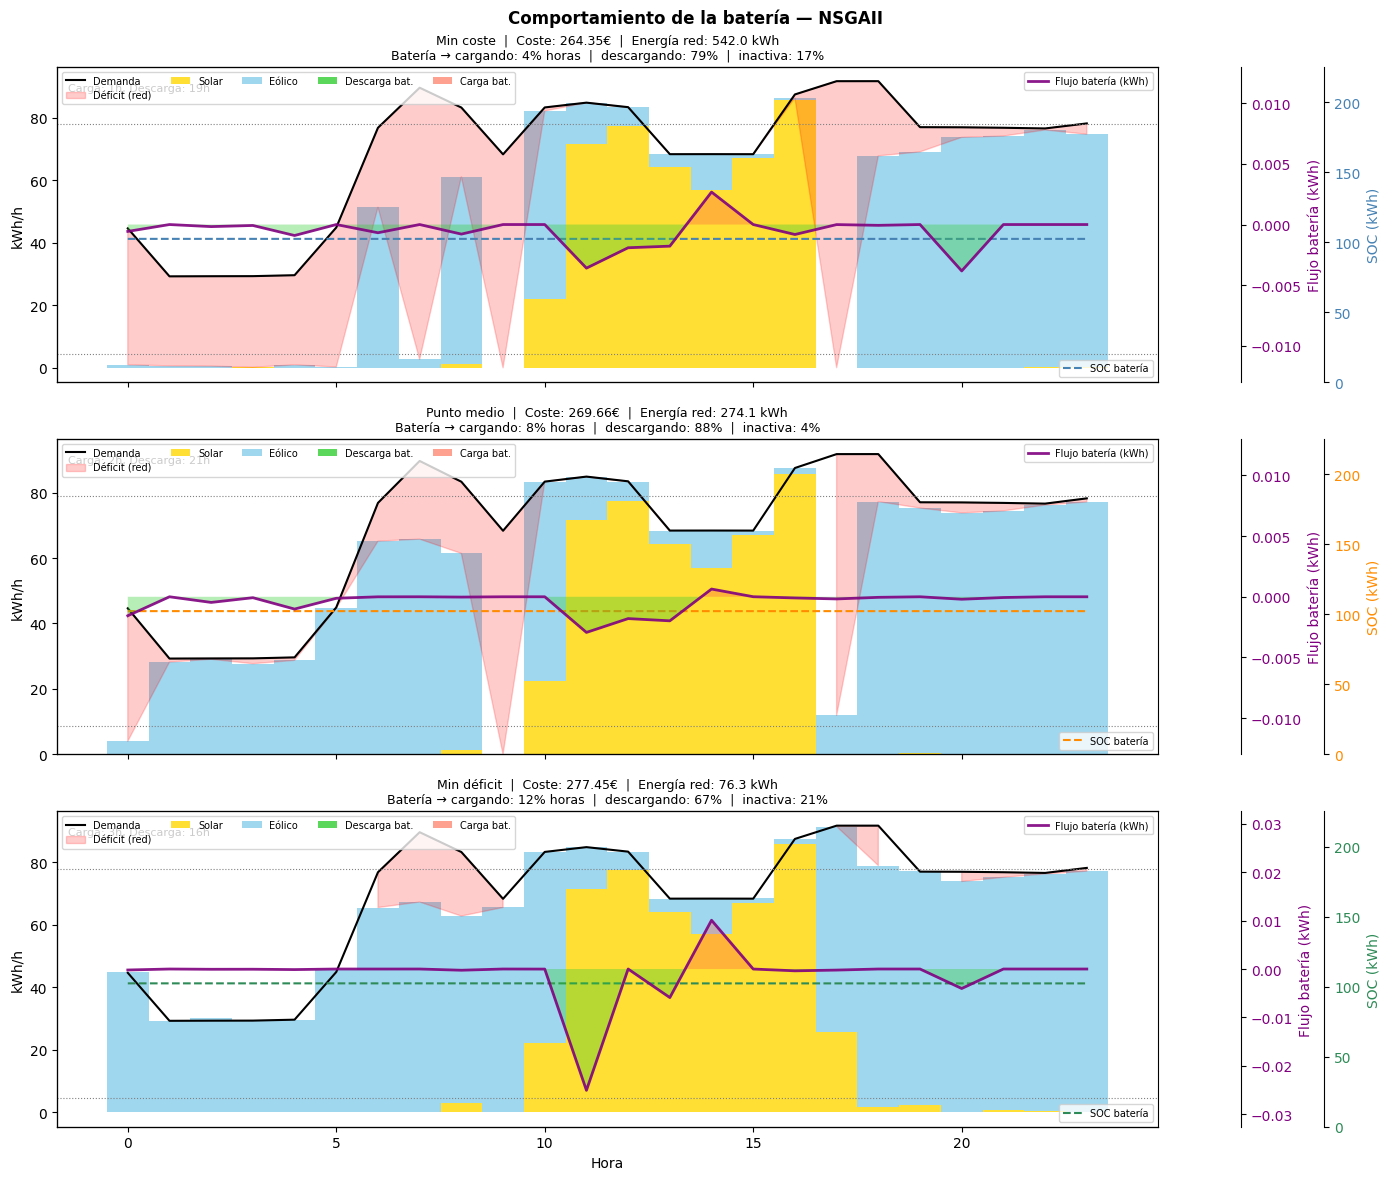

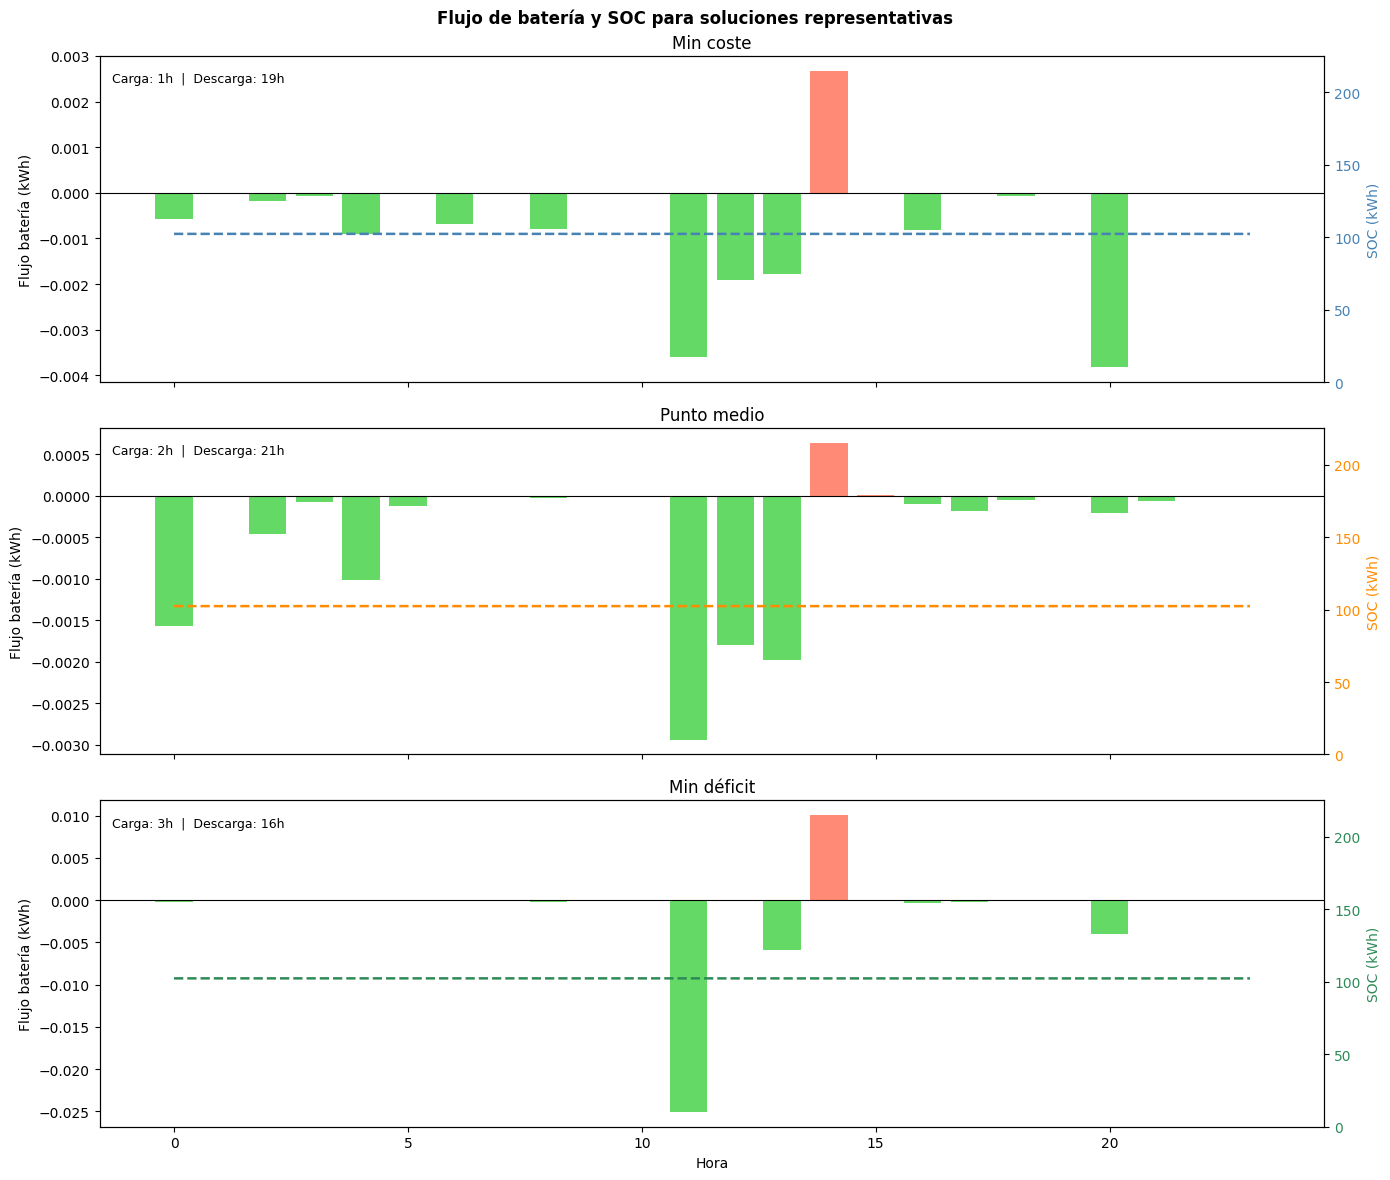


Solución        Coste (€)  Red (kWh)  % carga  % descarga  % inactiva  SOC medio
----------------------------------------------------------------------
Min coste          264.35      542.0     4.2%       79.2%       16.7%    102.41 kWh
Punto medio        269.66      274.1     8.3%       87.5%        4.2%    102.41 kWh
Min déficit        277.45       76.3    12.5%       66.7%       20.8%    102.40 kWh


In [64]:
# ============================================================
#  ANÁLISIS DEL USO DE LA BATERÍA EN EL FRENTE DE PARETO
# ============================================================
# Cada solución tiene 3*T variables: [x1 | x2 | b]
# Analizamos 3 soluciones representativas del frente:
#   - la de menor coste, la de menor déficit, y la del medio

if n_solutions > 0:
    idx_sorted = np.argsort(front_arr[:, 0])   # ordenadas por coste creciente
    idx_low_cost   = idx_sorted[0]             # menor coste
    idx_low_deficit= idx_sorted[-1]            # mayor coste = menor déficit
    idx_mid        = idx_sorted[len(idx_sorted)//2]  # punto medio

    labels   = ['Min coste', 'Punto medio', 'Min déficit']
    idxs     = [idx_low_cost, idx_mid, idx_low_deficit]
    colors   = ['steelblue', 'darkorange', 'seagreen']
    horas    = np.arange(T)

    print('Resumen de uso de batería en las soluciones representativas:')
    for label, idx in zip(labels, idxs):
        sol = front[idx]
        b = np.array(sol.variables)[2*T:]
        print(f'  {label}: min b={b.min():.4f} kWh, max b={b.max():.4f} kWh, '
              f'horas carga={int((b>0).sum())}, horas descarga={int((b<0).sum())}')

    fig, axes = plt.subplots(len(idxs), 1, figsize=(14, 4 * len(idxs)), sharex=True)

    for ax, idx, label, color in zip(axes, idxs, labels, colors):
        sol = front[idx]
        vars_ = np.array(sol.variables)
        x1 = vars_[:T]
        x2 = vars_[T:2*T]
        b  = vars_[2*T:]          # b>0 carga, b<0 descarga

        # Reconstruir SOC
        soc = [BATTERY_SOC_INI_KWH]
        for bt in b:
            if bt >= 0:
                soc.append(soc[-1] + bt * BATTERY_EFF_C)
            else:
                soc.append(soc[-1] + bt / BATTERY_EFF_D)
        soc = np.array(soc[:-1])   # alinear con horas

        supply = x1 + x2 - b
        grid   = np.maximum(0, DEMAND - supply)

        # Barras apiladas de suministro
        ax.bar(horas, x1,              label='Solar',     alpha=0.8, color='gold',      width=1.0)
        ax.bar(horas, x2, bottom=x1,   label='Eólico',    alpha=0.8, color='skyblue',   width=1.0)
        # Descarga de batería (b<0 → aporta; mostramos como positivo)
        discharge = np.maximum(0, -b)
        ax.bar(horas, discharge, bottom=x1+x2, label='Descarga bat.', alpha=0.8, color='limegreen', width=1.0)
        # Carga de batería (b>0 → resta; mostramos como negativo)
        charge = np.maximum(0, b)
        ax.bar(horas, -charge, label='Carga bat.', alpha=0.6, color='tomato', width=1.0)

        ax.plot(horas, DEMAND, 'k-', lw=1.5, label='Demanda')
        ax.fill_between(horas, supply, DEMAND,
                        where=supply < DEMAND,
                        alpha=0.2, color='red', label='Déficit (red)')

        # Mostrar flujo de batería en un eje adicional: carga > 0, descarga < 0
        ax3 = ax.twinx()
        ax3.spines['right'].set_position(('outward', 60))
        ax3.patch.set_alpha(0.0)
        ax3.set_zorder(ax.get_zorder() + 1)
        ax3.plot(horas, b, color='purple', lw=2.0, alpha=0.9, label='Flujo batería (kWh)')
        ax3.fill_between(horas, 0, b, where=b >= 0, interpolate=True,
                         facecolor='tomato', alpha=0.35)
        ax3.fill_between(horas, 0, b, where=b <= 0, interpolate=True,
                         facecolor='limegreen', alpha=0.35)
        ax3.set_ylabel('Flujo batería (kWh)', color='purple')
        ax3.tick_params(axis='y', labelcolor='purple')
        b_span = max(abs(b.min()), abs(b.max()), 1e-2)
        ax3.set_ylim(-b_span * 1.3, b_span * 1.3)
        ax3.legend(loc='upper right', fontsize=7)

        # Mostrar resumen de horas en carga/descarga
        n_carga = int((b > 0).sum())
        n_descarga = int((b < 0).sum())
        ax.text(0.01, 0.95,
                f'Carga: {n_carga}h, Descarga: {n_descarga}h',
                transform=ax.transAxes, va='top', ha='left', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

        # SOC en eje secundario
        ax2 = ax.twinx()
        ax2.spines['right'].set_position(('outward', 120))
        ax2.patch.set_alpha(0.0)
        ax2.plot(horas, soc, '--', color=color, lw=1.5, label='SOC batería')
        ax2.axhline(BATTERY_SOC_MIN_KWH, ls=':', color='gray', lw=0.8)
        ax2.axhline(BATTERY_SOC_MAX_KWH, ls=':', color='gray', lw=0.8)
        ax2.set_ylabel('SOC (kWh)', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_ylim(0, BATTERY_CAPACITY * 1.1)
        ax2.legend(loc='lower right', fontsize=7)
        ax2.legend(loc='lower right', fontsize=7)

        f1, f2 = sol.objectives
        pct_carga    = (b > 0).mean() * 100
        pct_descarga = (b < 0).mean() * 100
        pct_inactiva = (b == 0).mean() * 100

        ax.set_title(
            f'{label}  |  Coste: {f1:.2f}€  |  Energía red: {f2:.1f} kWh\n'
            f'Batería → cargando: {pct_carga:.0f}% horas  |  '
            f'descargando: {pct_descarga:.0f}%  |  inactiva: {pct_inactiva:.0f}%',
            fontsize=9
        )
        ax.set_ylabel('kWh/h')
        ax.legend(loc='upper left', fontsize=7, ncol=5)

    axes[-1].set_xlabel('Hora')
    plt.suptitle(f'Comportamiento de la batería — {algo_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Gráfico auxiliar explícito de carga/descarga y SOC ---
    fig2, axes2 = plt.subplots(len(idxs), 1, figsize=(14, 4 * len(idxs)), sharex=True)
    for ax, idx, label, color in zip(axes2, idxs, labels, colors):
        sol = front[idx]
        vars_ = np.array(sol.variables)
        b = vars_[2*T:]

        soc = [BATTERY_SOC_INI_KWH]
        for bt in b:
            soc.append(soc[-1] + bt * BATTERY_EFF_C if bt >= 0 else soc[-1] + bt / BATTERY_EFF_D)
        soc = np.array(soc[:-1])

        bar_colors = ['tomato' if bt > 0 else 'limegreen' if bt < 0 else 'lightgray' for bt in b]
        ax.bar(horas, b, color=bar_colors, alpha=0.75, width=0.8)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_ylabel('Flujo batería (kWh)')
        ax.set_title(label)

        ax2 = ax.twinx()
        ax2.plot(horas, soc, '--', color=color, lw=1.8, label='SOC batería')
        ax2.set_ylabel('SOC (kWh)', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.set_ylim(0, BATTERY_CAPACITY * 1.1)

        carga_h = int((b > 0).sum())
        descarga_h = int((b < 0).sum())
        ax.text(0.01, 0.95,
                f'Carga: {carga_h}h  |  Descarga: {descarga_h}h',
                transform=ax.transAxes, va='top', ha='left', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))

    axes2[-1].set_xlabel('Hora')
    plt.suptitle('Flujo de batería y SOC para soluciones representativas', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- Resumen tabular de las 3 soluciones ---
    print(f'\n{"Solución":<14} {"Coste (€)":>10} {"Red (kWh)":>10} '
          f'{"% carga":>8} {"% descarga":>11} {"% inactiva":>11} {"SOC medio":>10}')
    print('-' * 70)
    for idx, label in zip(idxs, labels):
        sol  = front[idx]
        vars_= np.array(sol.variables)
        b    = vars_[2*T:]
        soc_vals = [BATTERY_SOC_INI_KWH]
        for bt in b:
            soc_vals.append(soc_vals[-1] + bt * BATTERY_EFF_C if bt >= 0
                            else soc_vals[-1] + bt / BATTERY_EFF_D)
        print(f'{label:<14} {sol.objectives[0]:>10.2f} {sol.objectives[1]:>10.1f} '
              f'{(b>0).mean()*100:>7.1f}% {(b<0).mean()*100:>10.1f}% '
              f'{(b==0).mean()*100:>10.1f}% {np.mean(soc_vals[:-1]):>9.2f} kWh')

In [59]:
# Después de calcular supply y grid, añade esto dentro del bucle del for:

PRICE_THRESHOLD = np.median(A_GRID)  # umbral: mitad del tiempo es "caro"

ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))  # desplaza para no solapar SOC
ax3.plot(horas, A_GRID * 1000, color='purple', lw=0.8, alpha=0.6, label='Precio red (€/MWh)')
ax3.set_ylabel('€/MWh', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')

# Marcar horas donde carga batería en horas baratas (correcto)
carga_barata    = (b > 0) & (A_GRID < PRICE_THRESHOLD)
carga_cara      = (b > 0) & (A_GRID >= PRICE_THRESHOLD)
descarga_barata = (b < 0) & (A_GRID < PRICE_THRESHOLD)
descarga_cara   = (b < 0) & (A_GRID >= PRICE_THRESHOLD)

print(f'{label}:')
print(f'  Carga en horas baratas (✅): {carga_barata.mean()*100:.0f}%')
print(f'  Carga en horas caras  (❌): {carga_cara.mean()*100:.0f}%')
print(f'  Descarga en horas caras (✅): {descarga_cara.mean()*100:.0f}%')
print(f'  Descarga en horas baratas (❌): {descarga_barata.mean()*100:.0f}%')

Min déficit:
  Carga en horas baratas (✅): 8%
  Carga en horas caras  (❌): 4%
  Descarga en horas caras (✅): 25%
  Descarga en horas baratas (❌): 42%


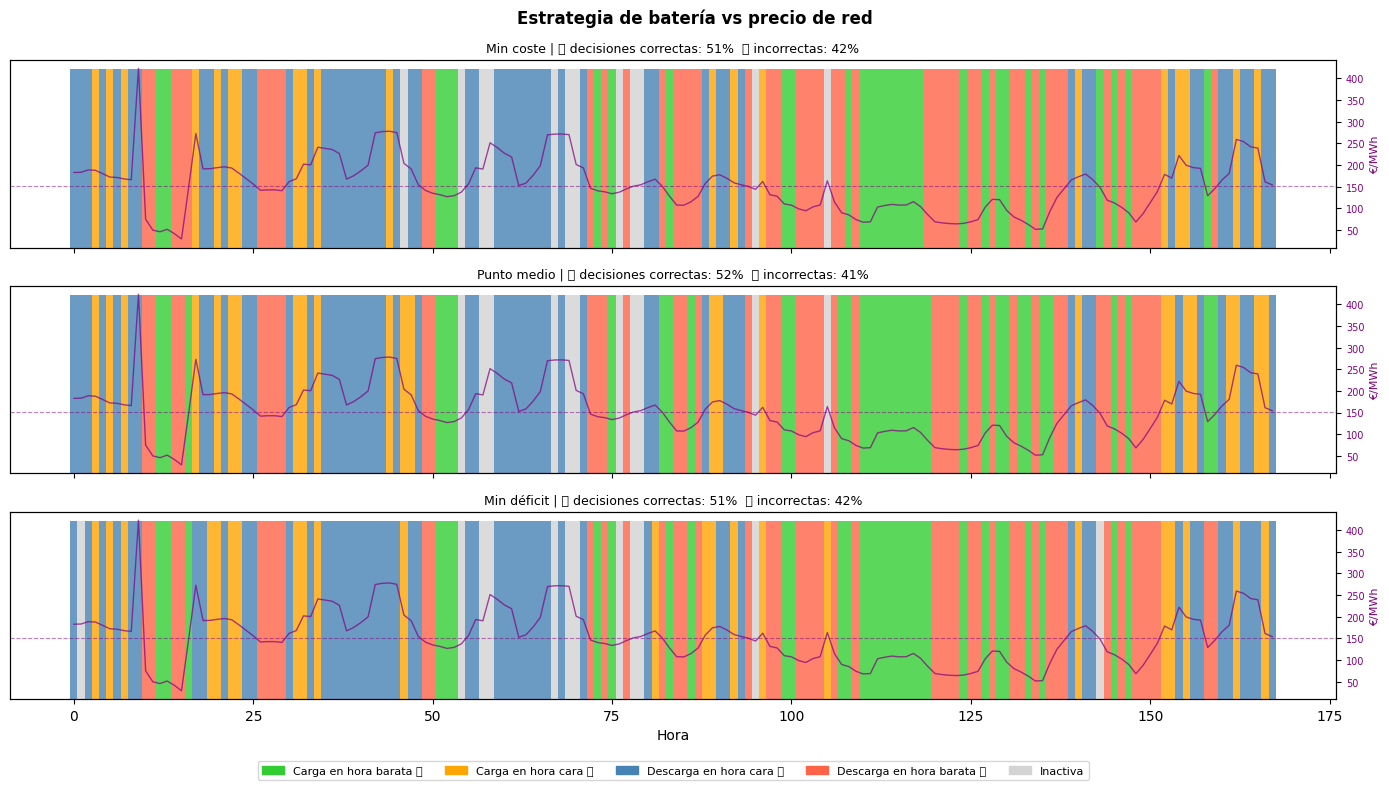

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
PRICE_THRESHOLD = np.median(A_GRID)

for ax, idx, label, color in zip(axes, idxs, labels, colors):
    sol = front[idx]
    vars_ = np.array(sol.variables)
    b = vars_[2*T:]

    # Clasificar cada hora
    estado = np.zeros(T)  # 0 = inactiva
    estado[(b > 0) & (A_GRID < PRICE_THRESHOLD)]  = 2   # carga barata ✅
    estado[(b > 0) & (A_GRID >= PRICE_THRESHOLD)] = 1   # carga cara  ❌
    estado[(b < 0) & (A_GRID >= PRICE_THRESHOLD)] = -2  # descarga cara ✅
    estado[(b < 0) & (A_GRID < PRICE_THRESHOLD)]  = -1  # descarga barata ❌

    # Heatmap
    ax.bar(np.arange(T), np.ones(T), color=[
        'limegreen' if e == 2 else
        'orange'    if e == 1 else
        'steelblue' if e == -2 else
        'tomato'    if e == -1 else
        'lightgray'
        for e in estado
    ], width=1.0, alpha=0.8)

    # Precio de red encima
    ax2 = ax.twinx()
    ax2.plot(np.arange(T), A_GRID * 1000, color='purple', lw=1.0, alpha=0.7)
    ax2.axhline(PRICE_THRESHOLD * 1000, ls='--', color='purple', lw=0.8, alpha=0.5)
    ax2.set_ylabel('€/MWh', color='purple', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='purple', labelsize=7)

    pct_ok = ((estado == 2) | (estado == -2)).mean() * 100
    pct_mal = ((estado == 1) | (estado == -1)).mean() * 100

    ax.set_title(f'{label} | ✅ decisiones correctas: {pct_ok:.0f}%  ❌ incorrectas: {pct_mal:.0f}%', fontsize=9)
    ax.set_yticks([])

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='limegreen', label='Carga en hora barata ✅'),
    Patch(color='orange',    label='Carga en hora cara ❌'),
    Patch(color='steelblue', label='Descarga en hora cara ✅'),
    Patch(color='tomato',    label='Descarga en hora barata ❌'),
    Patch(color='lightgray', label='Inactiva'),
]
axes[-1].legend(handles=legend_elements, loc='upper center',
                bbox_to_anchor=(0.5, -0.3), ncol=5, fontsize=8)
axes[-1].set_xlabel('Hora')
plt.suptitle('Estrategia de batería vs precio de red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Ejecutando SPEA2 con eta_c=20.0, eta_m=20.0, crossover_prob=0.9
Número de soluciones no dominadas: 92
Hypervolume frente de Pareto: 1469693.816166
Coste  : min 781.2307 € | max 790.0920 €
Energía red: min 359.60 kWh | max 608.82 kWh
Dispersión del frente: spacing media 2.747977, std 3.061114


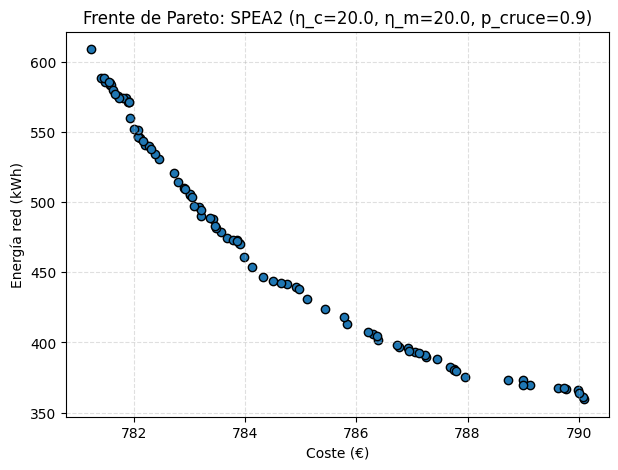

In [ ]:
# ============================================================
#  EJECUCIÓN DIRECTA DEL ALGORITMO (SIN GRID SEARCH)
# ============================================================
algo_name = 'SPEA2'
eta_c = 20.0
eta_m = 20.0
crossover_prob = 0.9
#eta_c          = best_params['SPEA2']['eta_c']
#eta_m          = best_params['SPEA2']['eta_m']
#crossover_prob = best_params['SPEA2']['crossover_prob']
seed = BASE_SEED

print(f'Ejecutando {algo_name} con eta_c={eta_c}, eta_m={eta_m}, crossover_prob={crossover_prob}')

random.seed(seed)
np.random.seed(seed)
mutation_prob = 1.0 / problem.number_of_variables()
max_evaluations = POPULATION_SIZE * GENERATIONS

crossover_op = SBXCrossover(probability=crossover_prob, distribution_index=eta_c)
mutation_op = PolynomialMutation(probability=mutation_prob, distribution_index=eta_m)
termination = StoppingByEvaluations(max_evaluations=max_evaluations)

if algo_name == 'NSGAII':
    algo = NSGAII(problem=problem, population_size=POPULATION_SIZE,
                  offspring_population_size=POPULATION_SIZE,
                  mutation=mutation_op, crossover=crossover_op,
                  termination_criterion=termination)
elif algo_name == 'SPEA2':
    algo = SPEA2(problem=problem, population_size=POPULATION_SIZE,
                 offspring_population_size=POPULATION_SIZE,
                 mutation=mutation_op, crossover=crossover_op,
                 termination_criterion=termination)
else:
    raise ValueError(f'Algoritmo desconocido: {algo_name}')

algo.run()
front = get_non_dominated_solutions(algo.result())
front_arr = np.array([s.objectives for s in front])

hv_ind = HyperVolume(REFERENCE_POINT.tolist())
hv = hv_ind.compute(front_arr.tolist()) if len(front_arr) > 0 else 0.0

n_solutions = len(front_arr)
print(f'Número de soluciones no dominadas: {n_solutions}')
print(f'Hypervolume frente de Pareto: {hv:.6f}')

if n_solutions > 0:
    coste_min, coste_max = front_arr[:, 0].min(), front_arr[:, 0].max()
    energia_min, energia_max = front_arr[:, 1].min(), front_arr[:, 1].max()
    sorted_by_cost = front_arr[np.argsort(front_arr[:, 0])]
    distances = np.linalg.norm(np.diff(sorted_by_cost, axis=0), axis=1)
    spacing_mean = float(distances.mean()) if len(distances) > 0 else 0.0
    spacing_std = float(distances.std()) if len(distances) > 0 else 0.0

    print(f'Coste  : min {coste_min:.4f} € | max {coste_max:.4f} €')
    print(f'Energía red: min {energia_min:.2f} kWh | max {energia_max:.2f} kWh')
    print(f'Dispersión del frente: spacing media {spacing_mean:.6f}, std {spacing_std:.6f}')

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
if n_solutions > 0:
    plt.scatter(front_arr[:, 0], front_arr[:, 1], c='C0', edgecolor='k')
plt.title(f'Frente de Pareto: {algo_name} (η_c={eta_c}, η_m={eta_m}, p_cruce={crossover_prob})')
plt.xlabel('Coste (€)')
plt.ylabel('Energía red (kWh)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 7. Guardar resultados

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.DataFrame(results).sort_values(
    ['algorithm', 'hv_median'], ascending=[True, False]).reset_index(drop=True)

ruta_csv = os.path.join(OUTPUT_DIR, 'resultados_optuna_microred.csv')
ruta_pkl = os.path.join(OUTPUT_DIR, 'resultados_optuna_microred.pkl')
df.to_csv(ruta_csv, index=False)
df.to_pickle(ruta_pkl)
print(f'Guardado:\n  {ruta_csv}\n  {ruta_pkl}')

# Guardar también la mejor configuración por algoritmo
with open(os.path.join(OUTPUT_DIR, 'best_params_microred.json'), 'w') as f:
    json.dump(best_params, f, indent=2)
print('  best_params_microred.json')
display(df.groupby('algorithm').head(5))